In [8]:
import numpy as np
import pandas as pd
from PyEMD import CEEMDAN
from vmdpy import VMD
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, GRU, Dense, Dropout
import tensorflow as tf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# --------------------------- 1. 数据加载与预处理 ---------------------------
def load_data(filepath):
    df = pd.read_excel(filepath, sheet_name='datas')
    df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y', dayfirst=True)
    df.set_index('date', inplace=True)
    full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
    return df.reindex(full_date_range).ffill()

df = load_data('C:/Users/18320/Desktop/carbon-Beijing.xlsx')
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df.values)

# --------------------------- 2. 固定参数设置 ---------------------------
# CEEMDAN参数
CEEMDAN_EPSILON = 0.02
CEEMDAN_ETA = 0.03

# VMD参数（用于高频模态二次分解）
VMD_ALPHA = 1400
VMD_K = 3

# BiLSTM参数
LSTM_UNITS = 128
GRU_UNITS = 128
DROPOUT_RATE = 0.3
LEARNING_RATE = 0.001
N_STEPS = 24
EPOCHS = 100
BATCH_SIZE = 32

# 聚类参数
N_CLUSTERS = 3

# 季节配置
seasons_config = [
    {
        'name': '秋季',
        'train_start': '2019-09-01',
        'train_end': '2024-08-31',
        'test_start': '2024-09-01',
        'test_end': '2024-11-30'
    }
]

# --------------------------- 3. 分解函数 ---------------------------
def ceemdan_decomposition(signal, epsilon, eta):
    """CEEMDAN分解"""
    ceemdan = CEEMDAN(epsilon=epsilon, 
                     eta=eta,
                     noise_strength=0.05,
                     ensemble_size=50)
    imfs = ceemdan.ceemdan(signal.flatten())
    return np.array(imfs).T

def vmd_decomposition(signal, alpha, K):
    """VMD分解"""
    imfs, _, _ = VMD(signal.flatten(), alpha=alpha, K=K, tau=0, DC=0, init=1, tol=1e-6)
    return imfs

# --------------------------- 4. IMF聚类函数 ---------------------------
def cluster_imfs(imfs, n_clusters=3):
    """基于频率特性对IMF进行聚类"""
    n_imfs = imfs.shape[1]
    features = []
    
    for i in range(n_imfs):
        imf = imfs[:, i]
        # 计算过零率（高频特征）
        zero_crossings = np.sum(np.diff(np.sign(imf)) != 0) / len(imf)
        
        # 计算能量（幅值特征）
        energy = np.sum(imf**2)
        
        # 计算自相关第一个零点（周期性特征）
        autocorr = np.correlate(imf, imf, mode='full')
        autocorr = autocorr[len(autocorr)//2:]
        first_zero = np.argmax(autocorr < 0.1 * autocorr[0]) if np.any(autocorr < 0.1 * autocorr[0]) else len(autocorr)-1
        
        features.append([zero_crossings, energy, first_zero])
    
    features = np.array(features)
    
    # 标准化特征
    feature_scaler = MinMaxScaler()
    normalized_features = feature_scaler.fit_transform(features)
    
    # K-means聚类
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(normalized_features)
    
    return labels, features, kmeans

# --------------------------- 5. IMF合并函数 ----------------------------
def merge_imfs_by_cluster(imfs, labels):
    """将同一聚类内的IMF合并为一个分量"""
    n_clusters = np.max(labels) + 1
    merged_components = []
    
    for cluster_id in range(n_clusters):
        # 找到属于当前聚类的所有IMF索引
        cluster_indices = np.where(labels == cluster_id)[0]
        
        if len(cluster_indices) > 0:
            # 将同一聚类内的IMF相加合并
            merged_component = np.sum(imfs[:, cluster_indices], axis=1)
            merged_components.append(merged_component)
    
    return np.array(merged_components).T

# --------------------------- 6. 高频模态VMD二次分解 ---------------------------
def refine_high_frequency_components(merged_components, labels, original_imfs, vmd_alpha, vmd_k):
    """对高频聚类分量进行VMD二次分解"""
    # 找到高频聚类（过零率最高的聚类）
    cluster_features = []
    for i in range(np.max(labels)+1):
        cluster_indices = np.where(labels == i)[0]
        if len(cluster_indices) > 0:
            # 使用原始IMF计算过零率
            avg_zero_crossing = np.mean([np.sum(np.diff(np.sign(original_imfs[:, idx])) != 0) / len(original_imfs) for idx in cluster_indices])
            cluster_features.append(avg_zero_crossing)
        else:
            cluster_features.append(0)
    
    high_freq_cluster = np.argmax(cluster_features)
    
    # 对高频聚类分量进行VMD二次分解
    refined_components = []
    for i in range(merged_components.shape[1]):
        if i == high_freq_cluster:
            # 对高频分量进行VMD分解
            vmd_imfs = vmd_decomposition(merged_components[:, i], vmd_alpha, vmd_k)
            refined_components.extend(vmd_imfs)
        else:
            # 非高频分量保持不变
            refined_components.append(merged_components[:, i])
    
    return np.array(refined_components).T, high_freq_cluster

# --------------------------- 7. 评估函数 ---------------------------
def evaluate(y_true, y_pred):
    """评估函数，计算多个指标"""
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-10))) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {
        'MSE': mse,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

# --------------------------- 8. 模型定义函数 ---------------------------
def create_bilstm_model(input_shape, units, dropout_rate, learning_rate):
    """创建BiLSTM模型"""
    model = Sequential([
        Bidirectional(LSTM(units, return_sequences=False), 
                     input_shape=input_shape),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                 loss='mse',
                 metrics=['mae'])
    return model

def create_gru_model(input_shape, units, dropout_rate, learning_rate):
    """创建GRU模型"""
    model = Sequential([
        GRU(units, return_sequences=False, input_shape=input_shape),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                 loss='mse',
                 metrics=['mae'])
    return model

# --------------------------- 9. 模型选择函数 ---------------------------
def select_best_model(y_true, y_pred_bilstm, y_pred_gru, metric='RMSE'):
    """根据评估指标选择最佳模型"""
    metrics_bilstm = evaluate(y_true, y_pred_bilstm)
    metrics_gru = evaluate(y_true, y_pred_gru)
    
    if metric == 'RMSE':
        if metrics_bilstm['RMSE'] <= metrics_gru['RMSE']:
            return 'BiLSTM', metrics_bilstm, y_pred_bilstm
        else:
            return 'GRU', metrics_gru, y_pred_gru
    elif metric == 'MSE':
        if metrics_bilstm['MSE'] <= metrics_gru['MSE']:
            return 'BiLSTM', metrics_bilstm, y_pred_bilstm
        else:
            return 'GRU', metrics_gru, y_pred_gru
    elif metric == 'MAE':
        if metrics_bilstm['MAE'] <= metrics_gru['MAE']:
            return 'BiLSTM', metrics_bilstm, y_pred_bilstm
        else:
            return 'GRU', metrics_gru, y_pred_gru
    elif metric == 'R2':
        if metrics_bilstm['R2'] >= metrics_gru['R2']:
            return 'BiLSTM', metrics_bilstm, y_pred_bilstm
        else:
            return 'GRU', metrics_gru, y_pred_gru
    else:
        # 默认使用RMSE
        if metrics_bilstm['RMSE'] <= metrics_gru['RMSE']:
            return 'BiLSTM', metrics_bilstm, y_pred_bilstm
        else:
            return 'GRU', metrics_gru, y_pred_gru

# --------------------------- 10. 对比模型函数 ---------------------------
def train_comparison_models(X_train, y_train, X_test, model_type):
    """训练对比模型"""
    n_components = X_train.shape[2]
    predictions = []
    
    for i in range(n_components):
        X_component = X_train[:, :, i].reshape(X_train.shape[0], X_train.shape[1], 1)
        y_component = y_train[:, i].reshape(-1, 1)
        
        if model_type == 'BiLSTM':
            model = create_bilstm_model((N_STEPS, 1), LSTM_UNITS, DROPOUT_RATE, LEARNING_RATE)
        elif model_type == 'GRU':
            model = create_gru_model((N_STEPS, 1), GRU_UNITS, DROPOUT_RATE, LEARNING_RATE)
        else:
            raise ValueError(f"未知模型类型: {model_type}")
        
        model.fit(
            X_component, y_component, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            verbose=0,
            validation_split=0.2
        )
        
        # 预测
        X_test_component = X_test[:, :, i].reshape(X_test.shape[0], X_test.shape[1], 1)
        pred = model.predict(X_test_component, verbose=0).flatten()
        predictions.append(pred)
    
    return np.array(predictions).T

# --------------------------- 11. 预测函数 ---------------------------
def predict_components(models, X_data):
    """使用各个模型预测各分量"""
    predictions = []
    for i, model in enumerate(models):
        X_component = X_data[:, :, i].reshape(X_data.shape[0], X_data.shape[1], 1)
        pred = model.predict(X_component, verbose=0)
        predictions.append(pred.flatten())
    return np.array(predictions).T

# --------------------------- 12. 季节实验函数 ---------------------------
def run_seasonal_experiment(season_config, components, df, scaled_data):
    """运行单个季节的实验"""
    season_name = season_config['name']
    print(f"\n{'='*60}")
    print(f"开始 {season_name} 实验")
    print(f"{'='*60}")
    
    # 准备数据
    X, y = [], []
    for i in range(N_STEPS, len(components)):
        X.append(components[i-N_STEPS:i])
        y.append(components[i])
    X, y = np.array(X), np.array(y)

    # 按日期划分训练集和测试集
    print(f"\n按日期划分 {season_name} 的训练集和测试集...")

    # 获取日期索引
    dates = df.index[N_STEPS:]  # 注意：由于使用了N_STEPS，实际日期从第N_STEPS+1天开始

    # 创建训练集和测试集的掩码
    train_mask = (dates >= pd.to_datetime(season_config['train_start'])) & (dates <= pd.to_datetime(season_config['train_end']))
    test_mask = (dates >= pd.to_datetime(season_config['test_start'])) & (dates <= pd.to_datetime(season_config['test_end']))

    # 应用掩码划分数据
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    print(f"{season_name} 数据划分完成:")
    print(f"训练集日期范围: {dates[train_mask].min().strftime('%Y-%m-%d')} 到 {dates[train_mask].max().strftime('%Y-%m-%d')}")
    print(f"测试集日期范围: {dates[test_mask].min().strftime('%Y-%m-%d')} 到 {dates[test_mask].max().strftime('%Y-%m-%d')}")
    print(f"训练集样本数: {X_train.shape[0]}")
    print(f"测试集样本数: {X_test.shape[0]}")

    # 检查是否有数据
    if X_train.shape[0] == 0:
        print(f"警告: {season_name} 训练集为空，跳过该季节")
        return None
    if X_test.shape[0] == 0:
        print(f"警告: {season_name} 测试集为空，跳过该季节")
        return None

    # 训练所有模型并进行对比
    all_results = {}

    # 1. 原模型: CEEMDAN-VMD-BILSTM-GRU (模型选择)
    print(f"\n训练 {season_name} 原模型: CEEMDAN-VMD-BILSTM-GRU")

    best_models = []
    best_model_names = []
    component_validation_results = []

    for i in range(components.shape[1]):
        print(f"  训练分量 {i+1}/{components.shape[1]}...")
        
        # 准备数据
        X_component = X_train[:, :, i].reshape(X_train.shape[0], X_train.shape[1], 1)
        y_component = y_train[:, i].reshape(-1, 1)
        
        # 训练BiLSTM模型
        bilstm_model = create_bilstm_model(
            input_shape=(N_STEPS, 1), 
            units=LSTM_UNITS, 
            dropout_rate=DROPOUT_RATE, 
            learning_rate=LEARNING_RATE
        )
        
        bilstm_model.fit(
            X_component, y_component, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            verbose=0,
            validation_split=0.2
        )
        
        # 训练GRU模型
        gru_model = create_gru_model(
            input_shape=(N_STEPS, 1), 
            units=GRU_UNITS, 
            dropout_rate=DROPOUT_RATE, 
            learning_rate=LEARNING_RATE
        )
        
        gru_model.fit(
            X_component, y_component, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            verbose=0,
            validation_split=0.2
        )
        
        # 在验证集上评估两个模型
        X_val_component = X_component[int(0.8 * len(X_component)):]
        y_val_component = y_component[int(0.8 * len(y_component)):]
        
        y_pred_bilstm = bilstm_model.predict(X_val_component, verbose=0).flatten()
        y_pred_gru = gru_model.predict(X_val_component, verbose=0).flatten()
        
        # 选择最佳模型
        best_model_name, best_metrics, _ = select_best_model(
            y_val_component.flatten(), 
            y_pred_bilstm, 
            y_pred_gru, 
            metric='RMSE'
        )
        
        if best_model_name == 'BiLSTM':
            best_models.append(bilstm_model)
        else:
            best_models.append(gru_model)
        
        best_model_names.append(best_model_name)
        component_validation_results.append({
            'component': i+1,
            'best_model': best_model_name,
            'validation_RMSE': best_metrics['RMSE']
        })

    # 预测各分量
    y_pred_components = predict_components(best_models, X_test)

    # 组合分量预测结果
    y_pred_combined = np.sum(y_pred_components, axis=1)

    # 反归一化
    y_pred_final = scaler.inverse_transform(y_pred_combined.reshape(-1, 1)).flatten()
    y_true_combined = np.sum(y_test, axis=1)
    y_true_final = scaler.inverse_transform(y_true_combined.reshape(-1, 1)).flatten()

    # 评估最终预测结果
    metrics_original = evaluate(y_true_final, y_pred_final)
    all_results['CEEMDAN-VMD-BILSTM-GRU'] = {
        'metrics': metrics_original,
        'predictions': y_pred_final,
        'model_names': best_model_names
    }

    print(f"\n{season_name} 原模型评估:")
    for k, v in metrics_original.items():
        print(f"  {k}: {v:.4f}")

    # 2. 对比模型1: CEEMDAN-BILSTM-GRU (无VMD二次分解)
    print(f"\n训练 {season_name} 对比模型1: CEEMDAN-BILSTM-GRU")

    # 使用合并后的分量（无VMD二次分解）
    components_no_vmd = merged_components

    # 准备数据
    X_no_vmd, y_no_vmd = [], []
    for i in range(N_STEPS, len(components_no_vmd)):
        X_no_vmd.append(components_no_vmd[i-N_STEPS:i])
        y_no_vmd.append(components_no_vmd[i])
    X_no_vmd, y_no_vmd = np.array(X_no_vmd), np.array(y_no_vmd)

    # 划分数据
    X_train_no_vmd, X_test_no_vmd = X_no_vmd[train_mask], X_no_vmd[test_mask]
    y_train_no_vmd, y_test_no_vmd = y_no_vmd[train_mask], y_no_vmd[test_mask]

    # 训练模型（使用模型选择）
    best_models_no_vmd = []
    best_model_names_no_vmd = []

    for i in range(components_no_vmd.shape[1]):
        X_component = X_train_no_vmd[:, :, i].reshape(X_train_no_vmd.shape[0], X_train_no_vmd.shape[1], 1)
        y_component = y_train_no_vmd[:, i].reshape(-1, 1)
        
        # 训练BiLSTM模型
        bilstm_model = create_bilstm_model((N_STEPS, 1), LSTM_UNITS, DROPOUT_RATE, LEARNING_RATE)
        bilstm_model.fit(X_component, y_component, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0, validation_split=0.2)
        
        # 训练GRU模型
        gru_model = create_gru_model((N_STEPS, 1), GRU_UNITS, DROPOUT_RATE, LEARNING_RATE)
        gru_model.fit(X_component, y_component, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0, validation_split=0.2)
        
        # 在验证集上评估
        X_val_component = X_component[int(0.8 * len(X_component)):]
        y_val_component = y_component[int(0.8 * len(y_component)):]
        
        y_pred_bilstm = bilstm_model.predict(X_val_component, verbose=0).flatten()
        y_pred_gru = gru_model.predict(X_val_component, verbose=0).flatten()
        
        # 选择最佳模型
        best_model_name, _, _ = select_best_model(y_val_component.flatten(), y_pred_bilstm, y_pred_gru, metric='RMSE')
        
        if best_model_name == 'BiLSTM':
            best_models_no_vmd.append(bilstm_model)
        else:
            best_models_no_vmd.append(gru_model)
        
        best_model_names_no_vmd.append(best_model_name)

    # 预测
    y_pred_components_no_vmd = predict_components(best_models_no_vmd, X_test_no_vmd)
    y_pred_combined_no_vmd = np.sum(y_pred_components_no_vmd, axis=1)

    # 反归一化
    y_pred_final_no_vmd = scaler.inverse_transform(y_pred_combined_no_vmd.reshape(-1, 1)).flatten()
    y_true_combined_no_vmd = np.sum(y_test_no_vmd, axis=1)
    y_true_final_no_vmd = scaler.inverse_transform(y_true_combined_no_vmd.reshape(-1, 1)).flatten()

    # 评估
    metrics_no_vmd = evaluate(y_true_final_no_vmd, y_pred_final_no_vmd)
    all_results['CEEMDAN-BILSTM-GRU'] = {
        'metrics': metrics_no_vmd,
        'predictions': y_pred_final_no_vmd,
        'model_names': best_model_names_no_vmd
    }

    print(f"\n{season_name} 对比模型1评估:")
    for k, v in metrics_no_vmd.items():
        print(f"  {k}: {v:.4f}")

    # 3. 对比模型2: CEEMDAN-VMD-BILSTM (只使用BiLSTM)
    print(f"\n训练 {season_name} 对比模型2: CEEMDAN-VMD-BILSTM")

    y_pred_components_bilstm = train_comparison_models(X_train, y_train, X_test, 'BiLSTM')
    y_pred_combined_bilstm = np.sum(y_pred_components_bilstm, axis=1)

    # 反归一化
    y_pred_final_bilstm = scaler.inverse_transform(y_pred_combined_bilstm.reshape(-1, 1)).flatten()
    metrics_bilstm = evaluate(y_true_final, y_pred_final_bilstm)
    all_results['CEEMDAN-VMD-BILSTM'] = {
        'metrics': metrics_bilstm,
        'predictions': y_pred_final_bilstm
    }

    print(f"\n{season_name} 对比模型2评估:")
    for k, v in metrics_bilstm.items():
        print(f"  {k}: {v:.4f}")

    # 4. 对比模型3: CEEMDAN-VMD-GRU (只使用GRU)
    print(f"\n训练 {season_name} 对比模型3: CEEMDAN-VMD-GRU")

    y_pred_components_gru = train_comparison_models(X_train, y_train, X_test, 'GRU')
    y_pred_combined_gru = np.sum(y_pred_components_gru, axis=1)

    # 反归一化
    y_pred_final_gru = scaler.inverse_transform(y_pred_combined_gru.reshape(-1, 1)).flatten()
    metrics_gru = evaluate(y_true_final, y_pred_final_gru)
    all_results['CEEMDAN-VMD-GRU'] = {
        'metrics': metrics_gru,
        'predictions': y_pred_final_gru
    }

    print(f"\n{season_name} 对比模型3评估:")
    for k, v in metrics_gru.items():
        print(f"  {k}: {v:.4f}")

    return {
        'season_name': season_name,
        'all_results': all_results,
        'y_true': y_true_final,
        'dates_test': dates[test_mask]
    }

# --------------------------- 13. 主程序 ---------------------------
# 使用固定参数进行分解和聚类
print("开始CEEMDAN分解...")
imfs = ceemdan_decomposition(scaled_data, CEEMDAN_EPSILON, CEEMDAN_ETA)
print(f"CEEMDAN分解完成，得到 {imfs.shape[1]} 个IMF分量")

print("开始K-means聚类...")
labels, features, kmeans = cluster_imfs(imfs, n_clusters=N_CLUSTERS)
print("K-means聚类完成")

# 合并同一聚类的IMF
print("开始合并同一聚类的IMF...")
merged_components = merge_imfs_by_cluster(imfs, labels)
print(f"IMF合并完成，得到 {merged_components.shape[1]} 个聚类分量")

print("开始高频模态VMD二次分解...")
components, high_freq_cluster = refine_high_frequency_components(
    merged_components, labels, imfs, VMD_ALPHA, VMD_K
)
print(f"VMD二次分解完成，最终得到 {components.shape[1]} 个分量")

# 输出聚类结果分析
print("\nIMF聚类分析:")
for i in range(N_CLUSTERS):
    cluster_imf_indices = np.where(labels == i)[0]
    print(f"聚类 {i+1} 包含 {len(cluster_imf_indices)} 个IMF: {cluster_imf_indices}")
    if len(cluster_imf_indices) > 0:
        print(f"  平均过零率: {np.mean(features[cluster_imf_indices, 0]):.4f}")
        print(f"  平均能量: {np.mean(features[cluster_imf_indices, 1]):.4f}")
        print(f"  平均周期: {np.mean(features[cluster_imf_indices, 2]):.2f}")

print(f"\n高频聚类（进行VMD二次分解）: 聚类 {high_freq_cluster+1}")

# 运行所有季节的实验
seasonal_results = []
for season_config in seasons_config:
    result = run_seasonal_experiment(season_config, components, df, scaled_data)
    if result is not None:
        seasonal_results.append(result)

# --------------------------- 14. 季节对比分析 ---------------------------
print("\n" + "="*60)
print("四季对比分析结果")
print("="*60)

# 创建季节对比表格
seasons_comparison = []

for season_result in seasonal_results:
    season_name = season_result['season_name']
    all_results = season_result['all_results']
    
    for model_name, result in all_results.items():
        metrics = result['metrics']
        seasons_comparison.append({
            'Season': season_name,
            'Model': model_name,
            'RMSE': metrics['RMSE'],
            'MAE': metrics['MAE'],
            'MSE': metrics['MSE'],
            'MAPE': metrics['MAPE'],
            'R2': metrics['R2']
        })

# 创建DataFrame
comparison_df = pd.DataFrame(seasons_comparison)

# 按季节和模型排序
comparison_df = comparison_df.sort_values(['Season', 'RMSE'])

print("\n各季节模型性能对比:")
for season in comparison_df['Season'].unique():
    print(f"\n{season}:")
    season_data = comparison_df[comparison_df['Season'] == season]
    for _, row in season_data.iterrows():
        print(f"  {row['Model']}: RMSE={row['RMSE']:.4f}, MAE={row['MAE']:.4f}, R²={row['R2']:.4f}")

# 找出每个季节的最佳模型
print("\n各季节最佳模型:")
best_models_by_season = []
for season in comparison_df['Season'].unique():
    season_data = comparison_df[comparison_df['Season'] == season]
    best_model = season_data.iloc[0]  # 因为已经按RMSE排序，第一个就是最好的
    best_models_by_season.append(best_model)
    print(f"  {season}: {best_model['Model']} (RMSE={best_model['RMSE']:.4f})")

# --------------------------- 15. 可视化结果 ---------------------------
# 1. 各季节模型性能对比热力图
plt.figure(figsize=(15, 12))

# 绘制各季节RMSE对比
plt.subplot(2, 2, 1)
models = ['CEEMDAN-VMD-BILSTM-GRU', 'CEEMDAN-BILSTM-GRU', 'CEEMDAN-VMD-BILSTM', 'CEEMDAN-VMD-GRU']
seasons = [result['season_name'] for result in seasonal_results]

rmse_matrix = np.zeros((len(seasons), len(models)))
for i, season in enumerate(seasons):
    for j, model in enumerate(models):
        mask = (comparison_df['Season'] == season) & (comparison_df['Model'] == model)
        if mask.any():
            rmse_matrix[i, j] = comparison_df[mask]['RMSE'].values[0]
        else:
            rmse_matrix[i, j] = np.nan

im = plt.imshow(rmse_matrix, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, label='RMSE')
plt.xticks(range(len(models)), models, rotation=45)
plt.yticks(range(len(seasons)), seasons)
plt.title('各季节模型RMSE对比热力图')

for i in range(len(seasons)):
    for j in range(len(models)):
        if not np.isnan(rmse_matrix[i, j]):
            plt.text(j, i, f'{rmse_matrix[i, j]:.3f}', 
                    ha='center', va='center', color='black', fontsize=10)

# 绘制各季节最佳模型
plt.subplot(2, 2, 2)
best_models_df = pd.DataFrame(best_models_by_season)
model_counts = best_models_df['Model'].value_counts()

plt.pie(model_counts.values, labels=model_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('各季节最佳模型分布')

# 绘制各模型在不同季节的RMSE变化
plt.subplot(2, 2, 3)
for model in models:
    model_data = comparison_df[comparison_df['Model'] == model]
    if not model_data.empty:
        plt.plot(model_data['Season'], model_data['RMSE'], 'o-', label=model, linewidth=2, markersize=8)

plt.xlabel('季节')
plt.ylabel('RMSE')
plt.title('各模型在不同季节的RMSE变化')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# 绘制各季节预测结果对比（只显示第一个季节的预测结果作为示例）
if seasonal_results:
    plt.subplot(2, 2, 4)
    first_season = seasonal_results[0]
    season_name = first_season['season_name']
    y_true = first_season['y_true']
    dates_test = first_season['dates_test']
    
    plt.plot(dates_test, y_true, label='真实值', linewidth=2, color='black')
    
    colors = ['red', 'blue', 'green', 'orange']
    for i, (model_name, result) in enumerate(first_season['all_results'].items()):
        plt.plot(dates_test, result['predictions'], label=model_name, alpha=0.8, color=colors[i])
    
    plt.title(f'{season_name}预测结果对比')
    plt.xlabel('日期')
    plt.ylabel('碳排放量')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 2. 详细季节对比图
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, season_result in enumerate(seasonal_results):
    if idx >= 4:  # 最多显示4个季节
        break
        
    season_name = season_result['season_name']
    y_true = season_result['y_true']
    dates_test = season_result['dates_test']
    all_results = season_result['all_results']
    
    ax = axes[idx]
    ax.plot(dates_test, y_true, label='真实值', linewidth=2, color='black')
    
    colors = ['red', 'blue', 'green', 'orange']
    for i, (model_name, result) in enumerate(all_results.items()):
        ax.plot(dates_test, result['predictions'], label=model_name, alpha=0.8, color=colors[i])
    
    ax.set_title(f'{season_name}预测结果对比')
    ax.set_xlabel('日期')
    ax.set_ylabel('碳排放量')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

print("\n所有季节实验完成!")

开始CEEMDAN分解...
CEEMDAN分解完成，得到 9 个IMF分量
开始K-means聚类...
K-means聚类完成
开始合并同一聚类的IMF...
IMF合并完成，得到 3 个聚类分量
开始高频模态VMD二次分解...
VMD二次分解完成，最终得到 5 个分量

IMF聚类分析:
聚类 1 包含 7 个IMF: [1 2 3 4 5 6 7]
  平均过零率: 0.0673
  平均能量: 18.7156
  平均周期: 89.71
聚类 2 包含 1 个IMF: [8]
  平均过零率: 0.0000
  平均能量: 203.6798
  平均周期: 1968.00
聚类 3 包含 1 个IMF: [0]
  平均过零率: 0.5187
  平均能量: 1.7677
  平均周期: 2.00

高频聚类（进行VMD二次分解）: 聚类 3

开始 秋季 实验

按日期划分 秋季 的训练集和测试集...
秋季 数据划分完成:
训练集日期范围: 2019-09-01 到 2024-08-31
测试集日期范围: 2024-09-01 到 2024-11-30
训练集样本数: 1827
测试集样本数: 91

训练 秋季 原模型: CEEMDAN-VMD-BILSTM-GRU
  训练分量 1/5...


KeyboardInterrupt: 

Starting CEEMDAN decomposition...
CEEMDAN decomposition completed, obtained 8 IMF components
Starting K-means clustering...
K-means clustering completed
Starting to merge IMFs within same cluster...
IMF merging completed, obtained 3 cluster components
Starting VMD secondary decomposition of high-frequency components...
VMD secondary decomposition completed, final 5 components obtained

IMF clustering analysis:
Cluster 1 contains 6 IMFs: [1 2 3 4 5 6]
  Average zero-crossing rate: 0.0780
  Average energy: 20.2954
  Average period: 58.33
Cluster 2 contains 1 IMFs: [7]
  Average zero-crossing rate: 0.0000
  Average energy: 178.3319
  Average period: 1983.00
Cluster 3 contains 1 IMFs: [0]
  Average zero-crossing rate: 0.5205
  Average energy: 1.7999
  Average period: 2.00

High-frequency cluster (for VMD secondary decomposition): Cluster 3

Starting Summer experiment

Splitting Summer data into train and test sets by date...
Summer data splitting completed:
Train set date range: 2019-03-25

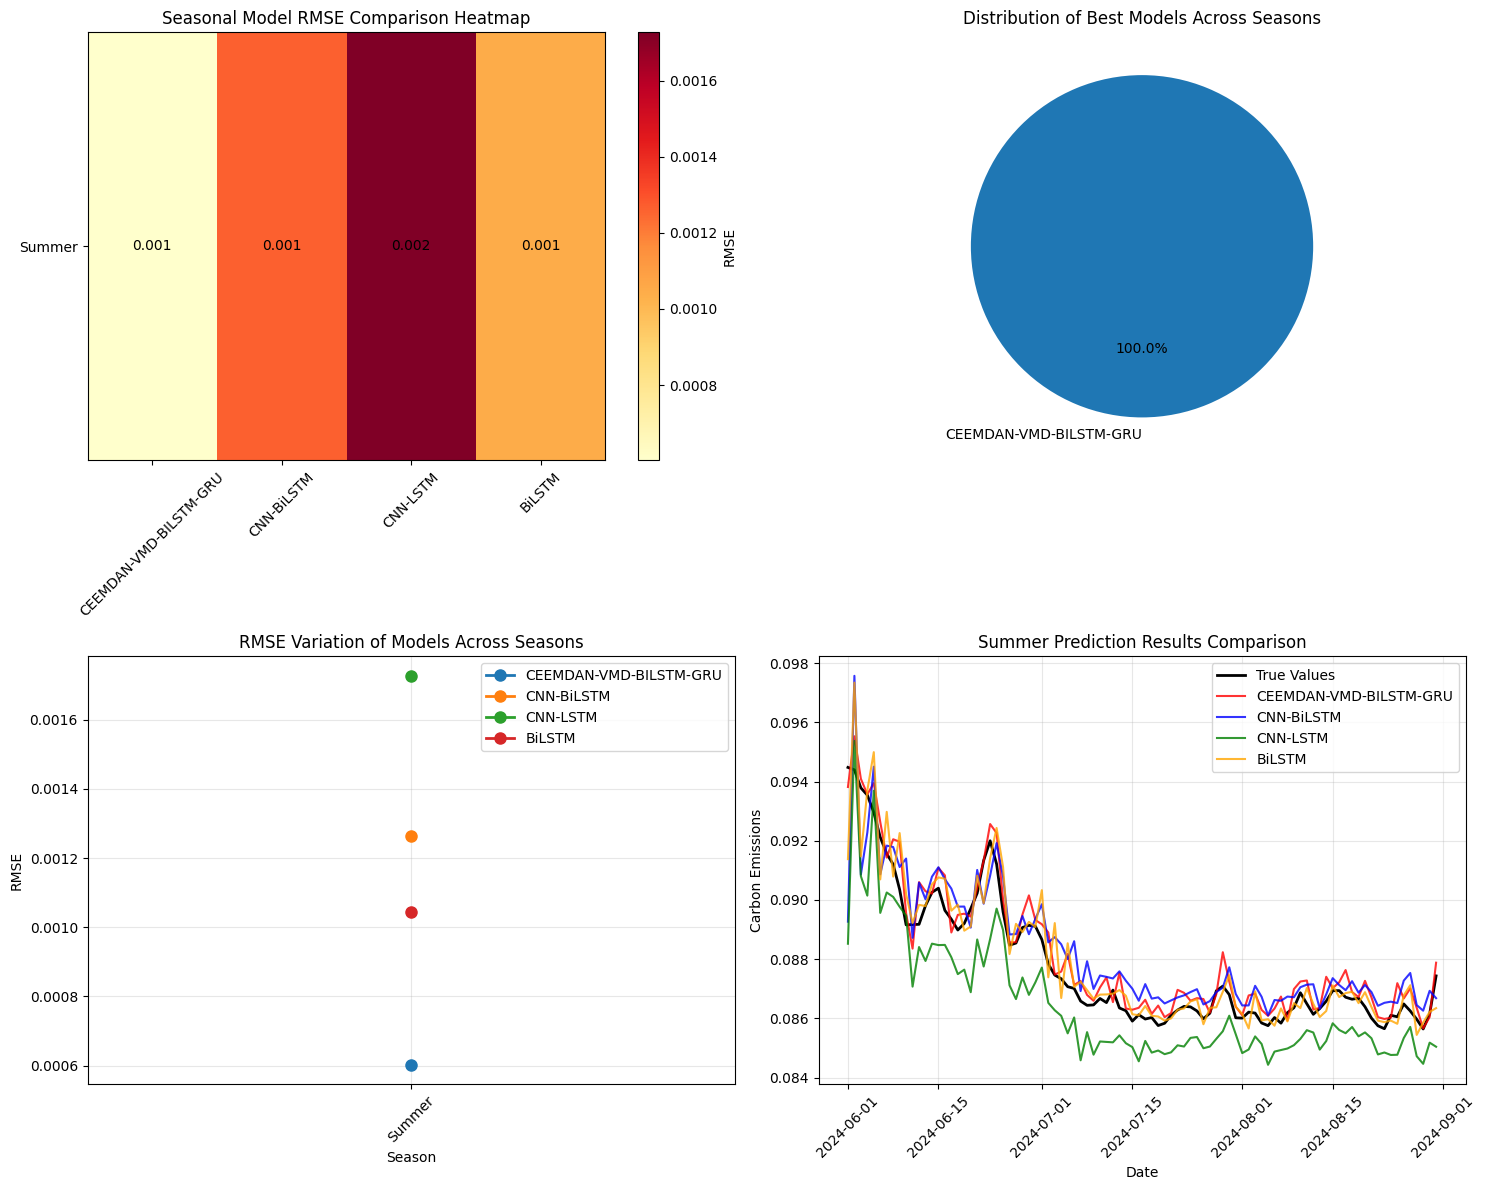

Detailed seasonal comparison figure saved to: figures\detailed_seasonal_comparison.png


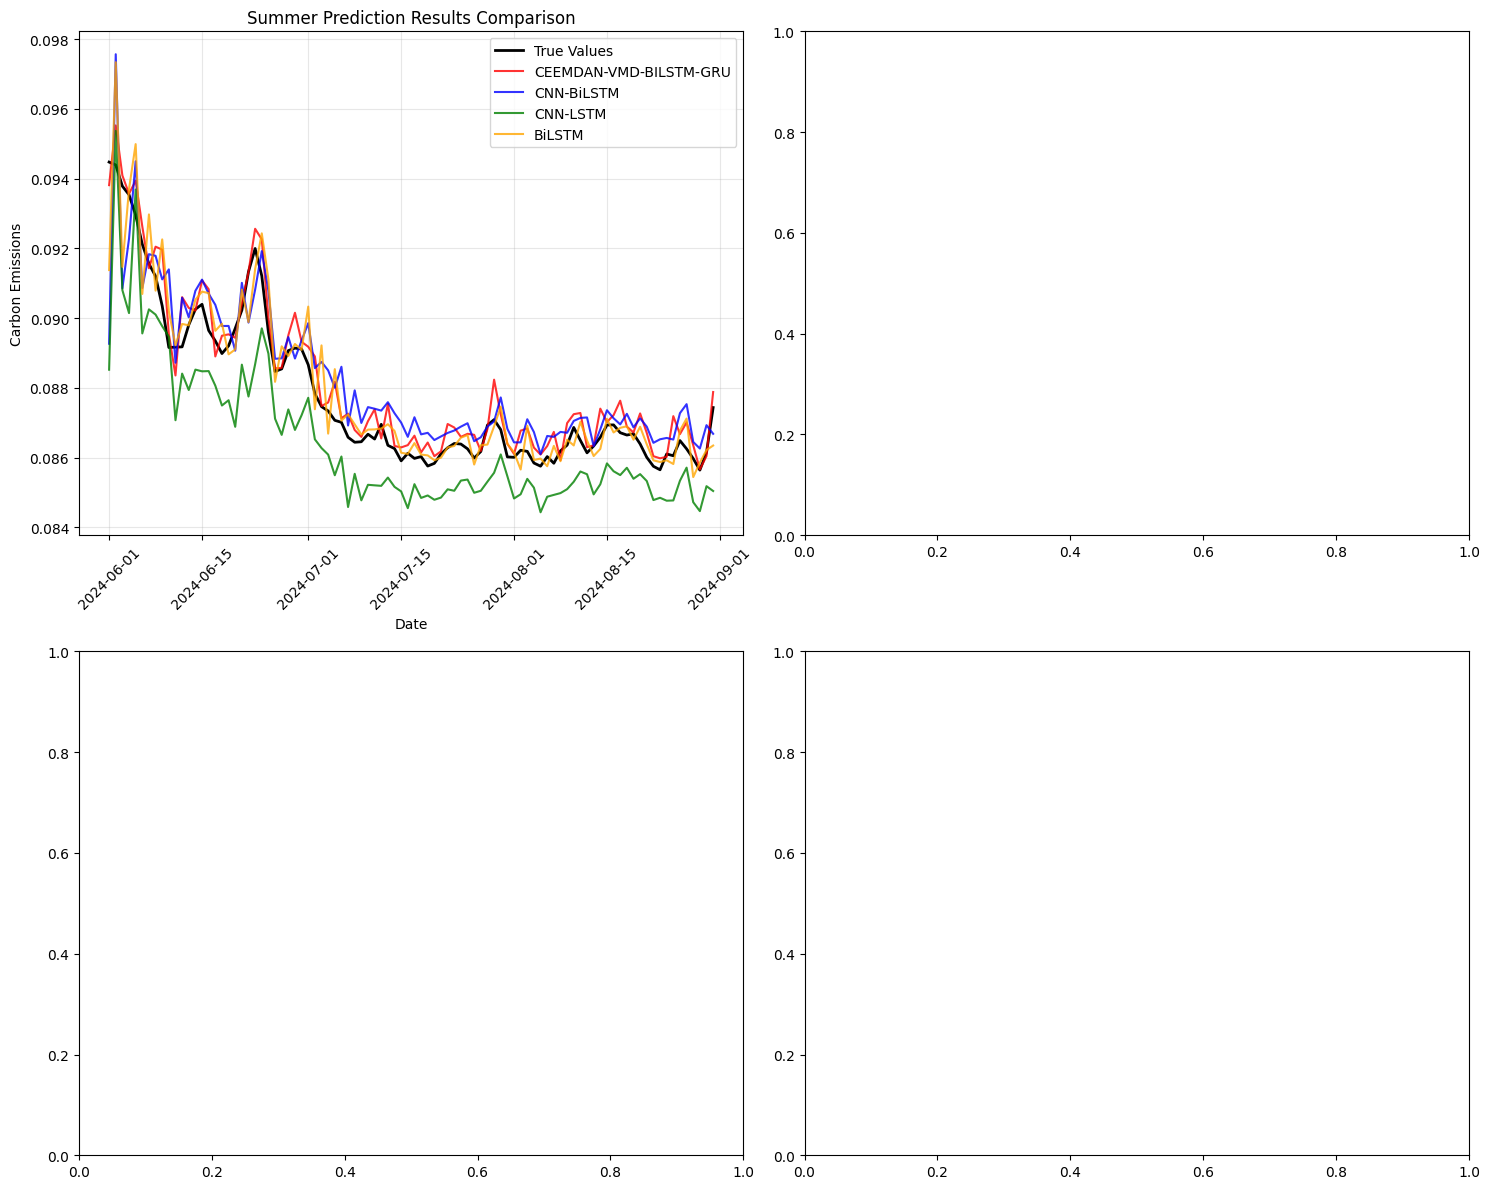

Summer prediction comparison figure saved to: figures\summer_prediction_comparison.png
Model comparison results saved to: figures\model_comparison_results.csv
Best models summary saved to: figures\best_models_summary.csv

All figures and data have been saved to the 'figures' directory.

All seasonal experiments completed!


In [9]:
import numpy as np
import pandas as pd
from PyEMD import CEEMDAN
from vmdpy import VMD
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, GRU, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

# Remove Chinese font settings to use default English fonts
plt.rcParams.update(plt.rcParamsDefault)

# Create directory for saving figures
figures_dir = "figures"
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)

# --------------------------- 1. Data Loading and Preprocessing ---------------------------
def load_data(filepath):
    df = pd.read_excel(filepath, sheet_name='datas')
    df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y', dayfirst=True)
    df.set_index('date', inplace=True)
    full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
    return df.reindex(full_date_range).ffill()

df = load_data('C:/Users/18320/Desktop/carbon-Beijing.xlsx')
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df.values)

# --------------------------- 2. Fixed Parameter Settings ---------------------------
# CEEMDAN parameters
CEEMDAN_EPSILON = 0.02
CEEMDAN_ETA = 0.03

# VMD parameters (for high-frequency component secondary decomposition)
VMD_ALPHA = 2000
VMD_K = 3

# Model parameters
LSTM_UNITS = 128
GRU_UNITS = 128
CNN_FILTERS = 64
CNN_KERNEL_SIZE = 3
DROPOUT_RATE = 0.3
LEARNING_RATE = 0.001
N_STEPS = 24
EPOCHS = 100
BATCH_SIZE = 32

# Clustering parameters
N_CLUSTERS = 3

# Season configuration
seasons_config = [
    {
        'name': 'Summer',
        'train_start': '2019-01-01',
        'train_end': '2024-05-31',
        'test_start': '2024-06-01',
        'test_end': '2024-08-31'
    }
]

# --------------------------- 3. Decomposition Functions ---------------------------
def ceemdan_decomposition(signal, epsilon, eta):
    """CEEMDAN decomposition"""
    ceemdan = CEEMDAN(epsilon=epsilon, 
                     eta=eta,
                     noise_strength=0.05,
                     ensemble_size=50)
    imfs = ceemdan.ceemdan(signal.flatten())
    return np.array(imfs).T

def vmd_decomposition(signal, alpha, K):
    """VMD decomposition"""
    imfs, _, _ = VMD(signal.flatten(), alpha=alpha, K=K, tau=0, DC=0, init=1, tol=1e-6)
    return imfs

# --------------------------- 4. IMF Clustering Function ---------------------------
def cluster_imfs(imfs, n_clusters=3):
    """Cluster IMFs based on frequency characteristics"""
    n_imfs = imfs.shape[1]
    features = []
    
    for i in range(n_imfs):
        imf = imfs[:, i]
        # Calculate zero-crossing rate (high-frequency feature)
        zero_crossings = np.sum(np.diff(np.sign(imf)) != 0) / len(imf)
        
        # Calculate energy (amplitude feature)
        energy = np.sum(imf**2)
        
        # Calculate first zero of autocorrelation (periodicity feature)
        autocorr = np.correlate(imf, imf, mode='full')
        autocorr = autocorr[len(autocorr)//2:]
        first_zero = np.argmax(autocorr < 0.1 * autocorr[0]) if np.any(autocorr < 0.1 * autocorr[0]) else len(autocorr)-1
        
        features.append([zero_crossings, energy, first_zero])
    
    features = np.array(features)
    
    # Normalize features
    feature_scaler = MinMaxScaler()
    normalized_features = feature_scaler.fit_transform(features)
    
    # K-means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(normalized_features)
    
    return labels, features, kmeans

# --------------------------- 5. IMF Merging Function ----------------------------
def merge_imfs_by_cluster(imfs, labels):
    """Merge IMFs within the same cluster into a single component"""
    n_clusters = np.max(labels) + 1
    merged_components = []
    
    for cluster_id in range(n_clusters):
        # Find all IMF indices belonging to current cluster
        cluster_indices = np.where(labels == cluster_id)[0]
        
        if len(cluster_indices) > 0:
            # Sum IMFs within same cluster
            merged_component = np.sum(imfs[:, cluster_indices], axis=1)
            merged_components.append(merged_component)
    
    return np.array(merged_components).T

# --------------------------- 6. High-frequency Component VMD Secondary Decomposition ---------------------------
def refine_high_frequency_components(merged_components, labels, original_imfs, vmd_alpha, vmd_k):
    """Apply VMD secondary decomposition to high-frequency cluster components"""
    # Find high-frequency cluster (cluster with highest zero-crossing rate)
    cluster_features = []
    for i in range(np.max(labels)+1):
        cluster_indices = np.where(labels == i)[0]
        if len(cluster_indices) > 0:
            # Calculate average zero-crossing rate using original IMFs
            avg_zero_crossing = np.mean([np.sum(np.diff(np.sign(original_imfs[:, idx])) != 0) / len(original_imfs) for idx in cluster_indices])
            cluster_features.append(avg_zero_crossing)
        else:
            cluster_features.append(0)
    
    high_freq_cluster = np.argmax(cluster_features)
    
    # Apply VMD secondary decomposition to high-frequency cluster component
    refined_components = []
    for i in range(merged_components.shape[1]):
        if i == high_freq_cluster:
            # Apply VMD decomposition to high-frequency component
            vmd_imfs = vmd_decomposition(merged_components[:, i], vmd_alpha, vmd_k)
            refined_components.extend(vmd_imfs)
        else:
            # Keep non-high-frequency components unchanged
            refined_components.append(merged_components[:, i])
    
    return np.array(refined_components).T, high_freq_cluster

# --------------------------- 7. Evaluation Function ---------------------------
def evaluate(y_true, y_pred):
    """Evaluation function, calculate multiple metrics"""
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-10))) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {
        'MSE': mse,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

# --------------------------- 8. Model Definition Functions ---------------------------
def create_bilstm_model(input_shape, units, dropout_rate, learning_rate):
    """Create BiLSTM model"""
    model = Sequential([
        Bidirectional(LSTM(units, return_sequences=False), 
                     input_shape=input_shape),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                 loss='mse',
                 metrics=['mae'])
    return model

def create_cnn_bilstm_model(input_shape, filters, kernel_size, lstm_units, dropout_rate, learning_rate):
    """Create CNN-BiLSTM model"""
    model = Sequential([
        Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', 
               input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Bidirectional(LSTM(lstm_units, return_sequences=False)),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                 loss='mse',
                 metrics=['mae'])
    return model

def create_cnn_lstm_model(input_shape, filters, kernel_size, lstm_units, dropout_rate, learning_rate):
    """Create CNN-LSTM model"""
    model = Sequential([
        Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', 
               input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        LSTM(lstm_units, return_sequences=False),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                 loss='mse',
                 metrics=['mae'])
    return model

def create_gru_model(input_shape, units, dropout_rate, learning_rate):
    """Create GRU model"""
    model = Sequential([
        GRU(units, return_sequences=False, input_shape=input_shape),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                 loss='mse',
                 metrics=['mae'])
    return model

# --------------------------- 9. Model Selection Function ---------------------------
def select_best_model(y_true, y_pred_bilstm, y_pred_gru, metric='RMSE'):
    """Select best model based on evaluation metric"""
    metrics_bilstm = evaluate(y_true, y_pred_bilstm)
    metrics_gru = evaluate(y_true, y_pred_gru)
    
    if metric == 'RMSE':
        if metrics_bilstm['RMSE'] <= metrics_gru['RMSE']:
            return 'BiLSTM', metrics_bilstm, y_pred_bilstm
        else:
            return 'GRU', metrics_gru, y_pred_gru
    elif metric == 'MSE':
        if metrics_bilstm['MSE'] <= metrics_gru['MSE']:
            return 'BiLSTM', metrics_bilstm, y_pred_bilstm
        else:
            return 'GRU', metrics_gru, y_pred_gru
    elif metric == 'MAE':
        if metrics_bilstm['MAE'] <= metrics_gru['MAE']:
            return 'BiLSTM', metrics_bilstm, y_pred_bilstm
        else:
            return 'GRU', metrics_gru, y_pred_gru
    elif metric == 'R2':
        if metrics_bilstm['R2'] >= metrics_gru['R2']:
            return 'BiLSTM', metrics_bilstm, y_pred_bilstm
        else:
            return 'GRU', metrics_gru, y_pred_gru
    else:
        # Default to RMSE
        if metrics_bilstm['RMSE'] <= metrics_gru['RMSE']:
            return 'BiLSTM', metrics_bilstm, y_pred_bilstm
        else:
            return 'GRU', metrics_gru, y_pred_gru

# --------------------------- 10. Baseline Model Training Function ---------------------------
def train_baseline_models(X_train, y_train, X_test, y_test, scaler):
    """Train baseline comparison models"""
    baseline_results = {}
    
    # 1. CNN-BiLSTM model
    print("Training CNN-BiLSTM model...")
    cnn_bilstm_model = create_cnn_bilstm_model(
        input_shape=(N_STEPS, 1),
        filters=CNN_FILTERS,
        kernel_size=CNN_KERNEL_SIZE,
        lstm_units=LSTM_UNITS,
        dropout_rate=DROPOUT_RATE,
        learning_rate=LEARNING_RATE
    )
    
    cnn_bilstm_model.fit(
        X_train.reshape(X_train.shape[0], X_train.shape[1], 1),
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        validation_split=0.2
    )
    
    y_pred_cnn_bilstm = cnn_bilstm_model.predict(
        X_test.reshape(X_test.shape[0], X_test.shape[1], 1), verbose=0
    ).flatten()
    
    # Inverse normalization
    y_pred_cnn_bilstm_final = scaler.inverse_transform(y_pred_cnn_bilstm.reshape(-1, 1)).flatten()
    y_true_final = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    metrics_cnn_bilstm = evaluate(y_true_final, y_pred_cnn_bilstm_final)
    baseline_results['CNN-BiLSTM'] = {
        'metrics': metrics_cnn_bilstm,
        'predictions': y_pred_cnn_bilstm_final
    }
    
    # 2. CNN-LSTM model
    print("Training CNN-LSTM model...")
    cnn_lstm_model = create_cnn_lstm_model(
        input_shape=(N_STEPS, 1),
        filters=CNN_FILTERS,
        kernel_size=CNN_KERNEL_SIZE,
        lstm_units=LSTM_UNITS,
        dropout_rate=DROPOUT_RATE,
        learning_rate=LEARNING_RATE
    )
    
    cnn_lstm_model.fit(
        X_train.reshape(X_train.shape[0], X_train.shape[1], 1),
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        validation_split=0.2
    )
    
    y_pred_cnn_lstm = cnn_lstm_model.predict(
        X_test.reshape(X_test.shape[0], X_test.shape[1], 1), verbose=0
    ).flatten()
    
    y_pred_cnn_lstm_final = scaler.inverse_transform(y_pred_cnn_lstm.reshape(-1, 1)).flatten()
    metrics_cnn_lstm = evaluate(y_true_final, y_pred_cnn_lstm_final)
    baseline_results['CNN-LSTM'] = {
        'metrics': metrics_cnn_lstm,
        'predictions': y_pred_cnn_lstm_final
    }
    
    # 3. BiLSTM model
    print("Training BiLSTM model...")
    bilstm_model = create_bilstm_model(
        input_shape=(N_STEPS, 1),
        units=LSTM_UNITS,
        dropout_rate=DROPOUT_RATE,
        learning_rate=LEARNING_RATE
    )
    
    bilstm_model.fit(
        X_train.reshape(X_train.shape[0], X_train.shape[1], 1),
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        validation_split=0.2
    )
    
    y_pred_bilstm = bilstm_model.predict(
        X_test.reshape(X_test.shape[0], X_test.shape[1], 1), verbose=0
    ).flatten()
    
    y_pred_bilstm_final = scaler.inverse_transform(y_pred_bilstm.reshape(-1, 1)).flatten()
    metrics_bilstm = evaluate(y_true_final, y_pred_bilstm_final)
    baseline_results['BiLSTM'] = {
        'metrics': metrics_bilstm,
        'predictions': y_pred_bilstm_final
    }
    
    return baseline_results, y_true_final

# --------------------------- 11. Prediction Function ---------------------------
def predict_components(models, X_data):
    """Predict each component using respective models"""
    predictions = []
    for i, model in enumerate(models):
        X_component = X_data[:, :, i].reshape(X_data.shape[0], X_data.shape[1], 1)
        pred = model.predict(X_component, verbose=0)
        predictions.append(pred.flatten())
    return np.array(predictions).T

# --------------------------- 12. Seasonal Experiment Function ---------------------------
def run_seasonal_experiment(season_config, components, df, scaled_data):
    """Run experiment for a single season"""
    season_name = season_config['name']
    print(f"\n{'='*60}")
    print(f"Starting {season_name} experiment")
    print(f"{'='*60}")
    
    # Prepare decomposition model data
    X, y = [], []
    for i in range(N_STEPS, len(components)):
        X.append(components[i-N_STEPS:i])
        y.append(components[i])
    X, y = np.array(X), np.array(y)

    # Split data by date into train and test sets
    print(f"\nSplitting {season_name} data into train and test sets by date...")

    # Get date indices
    dates = df.index[N_STEPS:]

    # Create masks for train and test sets
    train_mask = (dates >= pd.to_datetime(season_config['train_start'])) & (dates <= pd.to_datetime(season_config['train_end']))
    test_mask = (dates >= pd.to_datetime(season_config['test_start'])) & (dates <= pd.to_datetime(season_config['test_end']))

    # Apply masks to split data
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    print(f"{season_name} data splitting completed:")
    print(f"Train set date range: {dates[train_mask].min().strftime('%Y-%m-%d')} to {dates[train_mask].max().strftime('%Y-%m-%d')}")
    print(f"Test set date range: {dates[test_mask].min().strftime('%Y-%m-%d')} to {dates[test_mask].max().strftime('%Y-%m-%d')}")
    print(f"Train set samples: {X_train.shape[0]}")
    print(f"Test set samples: {X_test.shape[0]}")

    # Check if data exists
    if X_train.shape[0] == 0:
        print(f"Warning: {season_name} train set is empty, skipping this season")
        return None
    if X_test.shape[0] == 0:
        print(f"Warning: {season_name} test set is empty, skipping this season")
        return None

    all_results = {}

    # 1. Main model: CEEMDAN-VMD-BILSTM-GRU (model selection)
    print(f"\nTraining {season_name} main model: CEEMDAN-VMD-BILSTM-GRU")

    best_models = []
    best_model_names = []
    component_validation_results = []

    for i in range(components.shape[1]):
        print(f"  Training component {i+1}/{components.shape[1]}...")
        
        # Prepare data
        X_component = X_train[:, :, i].reshape(X_train.shape[0], X_train.shape[1], 1)
        y_component = y_train[:, i].reshape(-1, 1)
        
        # Train BiLSTM model
        bilstm_model = create_bilstm_model(
            input_shape=(N_STEPS, 1), 
            units=LSTM_UNITS, 
            dropout_rate=DROPOUT_RATE, 
            learning_rate=LEARNING_RATE
        )
        
        bilstm_model.fit(
            X_component, y_component, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            verbose=0,
            validation_split=0.2
        )
        
        # Train GRU model
        gru_model = create_gru_model(
            input_shape=(N_STEPS, 1), 
            units=GRU_UNITS, 
            dropout_rate=DROPOUT_RATE, 
            learning_rate=LEARNING_RATE
        )
        
        gru_model.fit(
            X_component, y_component, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            verbose=0,
            validation_split=0.2
        )
        
        # Evaluate both models on validation set
        X_val_component = X_component[int(0.8 * len(X_component)):]
        y_val_component = y_component[int(0.8 * len(y_component)):]
        
        y_pred_bilstm = bilstm_model.predict(X_val_component, verbose=0).flatten()
        y_pred_gru = gru_model.predict(X_val_component, verbose=0).flatten()
        
        # Select best model
        best_model_name, best_metrics, _ = select_best_model(
            y_val_component.flatten(), 
            y_pred_bilstm, 
            y_pred_gru, 
            metric='RMSE'
        )
        
        if best_model_name == 'BiLSTM':
            best_models.append(bilstm_model)
        else:
            best_models.append(gru_model)
        
        best_model_names.append(best_model_name)
        component_validation_results.append({
            'component': i+1,
            'best_model': best_model_name,
            'validation_RMSE': best_metrics['RMSE']
        })

    # Predict each component
    y_pred_components = predict_components(best_models, X_test)

    # Combine component predictions
    y_pred_combined = np.sum(y_pred_components, axis=1)

    # Inverse normalization
    y_pred_final = scaler.inverse_transform(y_pred_combined.reshape(-1, 1)).flatten()
    y_true_combined = np.sum(y_test, axis=1)
    y_true_final = scaler.inverse_transform(y_true_combined.reshape(-1, 1)).flatten()

    # Evaluate final prediction
    metrics_original = evaluate(y_true_final, y_pred_final)
    all_results['CEEMDAN-VMD-BILSTM-GRU'] = {
        'metrics': metrics_original,
        'predictions': y_pred_final,
        'model_names': best_model_names
    }

    print(f"\n{season_name} main model evaluation:")
    for k, v in metrics_original.items():
        print(f"  {k}: {v:.4f}")

    # 2. Baseline comparison models: CNN-BiLSTM, CNN-LSTM, BiLSTM
    print(f"\nTraining {season_name} baseline comparison models...")
    
    # Prepare baseline model data (using original sequence)
    X_baseline, y_baseline = [], []
    for i in range(N_STEPS, len(scaled_data)):
        X_baseline.append(scaled_data[i-N_STEPS:i])
        y_baseline.append(scaled_data[i])
    X_baseline, y_baseline = np.array(X_baseline), np.array(y_baseline)
    
    # Split baseline model data
    X_train_baseline, X_test_baseline = X_baseline[train_mask], X_baseline[test_mask]
    y_train_baseline, y_test_baseline = y_baseline[train_mask], y_baseline[test_mask]
    
    # Train baseline models
    baseline_results, y_true_baseline = train_baseline_models(
        X_train_baseline, y_train_baseline, X_test_baseline, y_test_baseline, scaler
    )
    
    # Merge baseline model results
    all_results.update(baseline_results)
    
    print(f"\n{season_name} baseline model evaluation:")
    for model_name, result in baseline_results.items():
        print(f"  {model_name}:")
        for k, v in result['metrics'].items():
            print(f"    {k}: {v:.4f}")

    return {
        'season_name': season_name,
        'all_results': all_results,
        'y_true': y_true_final,
        'dates_test': dates[test_mask]
    }

# --------------------------- 13. Main Program ---------------------------
# Decomposition and clustering using fixed parameters
print("Starting CEEMDAN decomposition...")
imfs = ceemdan_decomposition(scaled_data, CEEMDAN_EPSILON, CEEMDAN_ETA)
print(f"CEEMDAN decomposition completed, obtained {imfs.shape[1]} IMF components")

print("Starting K-means clustering...")
labels, features, kmeans = cluster_imfs(imfs, n_clusters=N_CLUSTERS)
print("K-means clustering completed")

# Merge IMFs within same cluster
print("Starting to merge IMFs within same cluster...")
merged_components = merge_imfs_by_cluster(imfs, labels)
print(f"IMF merging completed, obtained {merged_components.shape[1]} cluster components")

print("Starting VMD secondary decomposition of high-frequency components...")
components, high_freq_cluster = refine_high_frequency_components(
    merged_components, labels, imfs, VMD_ALPHA, VMD_K
)
print(f"VMD secondary decomposition completed, final {components.shape[1]} components obtained")

# Output clustering result analysis
print("\nIMF clustering analysis:")
for i in range(N_CLUSTERS):
    cluster_imf_indices = np.where(labels == i)[0]
    print(f"Cluster {i+1} contains {len(cluster_imf_indices)} IMFs: {cluster_imf_indices}")
    if len(cluster_imf_indices) > 0:
        print(f"  Average zero-crossing rate: {np.mean(features[cluster_imf_indices, 0]):.4f}")
        print(f"  Average energy: {np.mean(features[cluster_imf_indices, 1]):.4f}")
        print(f"  Average period: {np.mean(features[cluster_imf_indices, 2]):.2f}")

print(f"\nHigh-frequency cluster (for VMD secondary decomposition): Cluster {high_freq_cluster+1}")

# Run experiments for all seasons
seasonal_results = []
for season_config in seasons_config:
    result = run_seasonal_experiment(season_config, components, df, scaled_data)
    if result is not None:
        seasonal_results.append(result)

# --------------------------- 14. Seasonal Comparison Analysis ---------------------------
print("\n" + "="*60)
print("Seasonal Comparison Analysis Results")
print("="*60)

# Create seasonal comparison table
seasons_comparison = []

for season_result in seasonal_results:
    season_name = season_result['season_name']
    all_results = season_result['all_results']
    
    for model_name, result in all_results.items():
        metrics = result['metrics']
        seasons_comparison.append({
            'Season': season_name,
            'Model': model_name,
            'RMSE': metrics['RMSE'],
            'MAE': metrics['MAE'],
            'MSE': metrics['MSE'],
            'MAPE': metrics['MAPE'],
            'R2': metrics['R2']
        })

# Create DataFrame
comparison_df = pd.DataFrame(seasons_comparison)

# Sort by season and model
comparison_df = comparison_df.sort_values(['Season', 'RMSE'])

print("\nModel performance comparison across seasons:")
for season in comparison_df['Season'].unique():
    print(f"\n{season}:")
    season_data = comparison_df[comparison_df['Season'] == season]
    for _, row in season_data.iterrows():
        print(f"  {row['Model']}: RMSE={row['RMSE']:.4f}, MAE={row['MAE']:.4f}, R²={row['R2']:.4f}")

# Find best model for each season
print("\nBest model for each season:")
best_models_by_season = []
for season in comparison_df['Season'].unique():
    season_data = comparison_df[comparison_df['Season'] == season]
    best_model = season_data.iloc[0]  # Already sorted by RMSE, first is best
    best_models_by_season.append(best_model)
    print(f"  {season}: {best_model['Model']} (RMSE={best_model['RMSE']:.4f})")

# --------------------------- 15. Visualization Results ---------------------------
# 1. Seasonal model performance comparison heatmap
plt.figure(figsize=(15, 12))

# Plot RMSE comparison across seasons
plt.subplot(2, 2, 1)
models = ['CEEMDAN-VMD-BILSTM-GRU', 'CNN-BiLSTM', 'CNN-LSTM', 'BiLSTM']
seasons = [result['season_name'] for result in seasonal_results]

rmse_matrix = np.zeros((len(seasons), len(models)))
for i, season in enumerate(seasons):
    for j, model in enumerate(models):
        mask = (comparison_df['Season'] == season) & (comparison_df['Model'] == model)
        if mask.any():
            rmse_matrix[i, j] = comparison_df[mask]['RMSE'].values[0]
        else:
            rmse_matrix[i, j] = np.nan

im = plt.imshow(rmse_matrix, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, label='RMSE')
plt.xticks(range(len(models)), models, rotation=45)
plt.yticks(range(len(seasons)), seasons)
plt.title('Seasonal Model RMSE Comparison Heatmap')

for i in range(len(seasons)):
    for j in range(len(models)):
        if not np.isnan(rmse_matrix[i, j]):
            plt.text(j, i, f'{rmse_matrix[i, j]:.3f}', 
                    ha='center', va='center', color='black', fontsize=10)

# Plot best models for each season
plt.subplot(2, 2, 2)
best_models_df = pd.DataFrame(best_models_by_season)
model_counts = best_models_df['Model'].value_counts()

plt.pie(model_counts.values, labels=model_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Best Models Across Seasons')

# Plot RMSE variation of each model across seasons
plt.subplot(2, 2, 3)
for model in models:
    model_data = comparison_df[comparison_df['Model'] == model]
    if not model_data.empty:
        plt.plot(model_data['Season'], model_data['RMSE'], 'o-', label=model, linewidth=2, markersize=8)

plt.xlabel('Season')
plt.ylabel('RMSE')
plt.title('RMSE Variation of Models Across Seasons')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Plot prediction results comparison (show only first season as example)
if seasonal_results:
    plt.subplot(2, 2, 4)
    first_season = seasonal_results[0]
    season_name = first_season['season_name']
    y_true = first_season['y_true']
    dates_test = first_season['dates_test']
    
    plt.plot(dates_test, y_true, label='True Values', linewidth=2, color='black')
    
    colors = ['red', 'blue', 'green', 'orange']
    for i, model_name in enumerate(models):
        if model_name in first_season['all_results']:
            plt.plot(dates_test, first_season['all_results'][model_name]['predictions'], 
                    label=model_name, alpha=0.8, color=colors[i])
    
    plt.title(f'{season_name} Prediction Results Comparison')
    plt.xlabel('Date')
    plt.ylabel('Carbon Emissions')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

plt.tight_layout()

# Save the first figure (summary figure)
summary_fig_path = os.path.join(figures_dir, 'seasonal_comparison_summary.png')
plt.savefig(summary_fig_path, dpi=300, bbox_inches='tight')
print(f"\nSummary figure saved to: {summary_fig_path}")
plt.show()

# 2. Detailed seasonal comparison plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, season_result in enumerate(seasonal_results):
    if idx >= 4:  # Show at most 4 seasons
        break
        
    season_name = season_result['season_name']
    y_true = season_result['y_true']
    dates_test = season_result['dates_test']
    all_results = season_result['all_results']
    
    ax = axes[idx]
    ax.plot(dates_test, y_true, label='True Values', linewidth=2, color='black')
    
    colors = ['red', 'blue', 'green', 'orange']
    for i, model_name in enumerate(models):
        if model_name in all_results:
            ax.plot(dates_test, all_results[model_name]['predictions'], 
                   label=model_name, alpha=0.8, color=colors[i])
    
    ax.set_title(f'{season_name} Prediction Results Comparison')
    ax.set_xlabel('Date')
    ax.set_ylabel('Carbon Emissions')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()

# Save the second figure (detailed seasonal comparison)
detailed_fig_path = os.path.join(figures_dir, 'detailed_seasonal_comparison.png')
plt.savefig(detailed_fig_path, dpi=300, bbox_inches='tight')
print(f"Detailed seasonal comparison figure saved to: {detailed_fig_path}")
plt.show()

# 3. Save individual seasonal prediction plots
for idx, season_result in enumerate(seasonal_results):
    season_name = season_result['season_name']
    y_true = season_result['y_true']
    dates_test = season_result['dates_test']
    all_results = season_result['all_results']
    
    plt.figure(figsize=(12, 6))
    plt.plot(dates_test, y_true, label='True Values', linewidth=2, color='black')
    
    colors = ['red', 'blue', 'green', 'orange']
    for i, model_name in enumerate(models):
        if model_name in all_results:
            plt.plot(dates_test, all_results[model_name]['predictions'], 
                    label=model_name, alpha=0.8, color=colors[i])
    
    plt.title(f'{season_name} Prediction Results Comparison')
    plt.xlabel('Date')
    plt.ylabel('Carbon Emissions')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Save individual season plot
    season_fig_path = os.path.join(figures_dir, f'{season_name.lower()}_prediction_comparison.png')
    plt.savefig(season_fig_path, dpi=300, bbox_inches='tight')
    print(f"{season_name} prediction comparison figure saved to: {season_fig_path}")
    plt.close()  # Close the figure to free memory

# 4. Save comparison results to CSV
comparison_csv_path = os.path.join(figures_dir, 'model_comparison_results.csv')
comparison_df.to_csv(comparison_csv_path, index=False)
print(f"Model comparison results saved to: {comparison_csv_path}")

# 5. Save best model selection results
best_models_csv_path = os.path.join(figures_dir, 'best_models_summary.csv')
best_models_summary = pd.DataFrame(best_models_by_season)
best_models_summary.to_csv(best_models_csv_path, index=False)
print(f"Best models summary saved to: {best_models_csv_path}")

print(f"\nAll figures and data have been saved to the '{figures_dir}' directory.")
print("\nAll seasonal experiments completed!")